## Instruction for reproducing the Figure panels
### 1. Clone the github repositories github:sahoo00/Hegemon and sahoo00/BoNE
### 2. Download the data [GSE119087](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE119087)
### 3. Organize the data folder
### 4. Run this Notebook

In [1]:
# IMPORT STATEMENTS
import sys
sys.path.append("/booleanfs2/sahoo/Hegemon/")
sys.path = ["/booleanfs2/sahoo/BoNE/"] + sys.path

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

try:
    reload  # Python 2.7
except NameError:
    try:
        from importlib import reload  # Python 3.4+
    except ImportError:
        from imp import reload  # Python 3.0 - 3.3
        
import SMaRT.MacUtils as mut
reload(mut)

<module 'SMaRT.MacUtils' from '/booleanfs2/sahoo/BoNE/SMaRT/MacUtils.py'>

In [2]:
import bone
reload(bone)
import Datasets
reload(Datasets)
pd = bone.pd
np = bone.np
re = bone.re
hu = bone.hu

In [3]:
ana = bone.IBDAnalysis()
ana.prepareData("GL1", cfile="data/explore.conf")
id1 = list(ana.h.getIDs("DCN").keys())[0]
print(id1)
order = [i for i in ana.h.aRange()]
dcres = bone.getRelStatsJava(ana, id1, order, sthr=3, pthr=0.1)
print([(k, len(dcres[k])) for k in dcres])

201893_x_at
[(0, 50738), (4, 2656), (2, 885), (3, 380), (5, 17)]


In [4]:
ana = bone.IBDAnalysis()
ana.prepareData("GL1", cfile="data/explore.conf")
id1 = list(ana.h.getIDs("TYROBP").keys())[0]
print(id1)
order = [i for i in ana.h.aRange()]
tyres = bone.getRelStatsJava(ana, id1, order, sthr=3, pthr=0.1)
print([(k, len(tyres[k])) for k in tyres])

204122_at
[(0, 52562), (2, 648), (4, 1309), (1, 10), (5, 10), (3, 137)]


## Figure 1

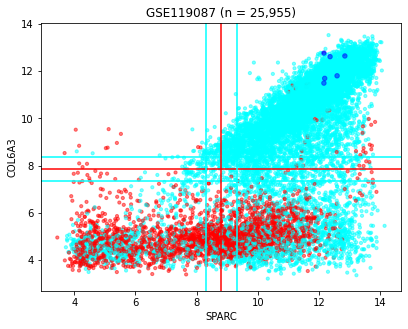

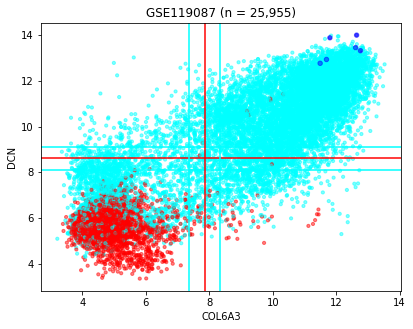

In [5]:
ana = bone.IBDAnalysis()
ana.prepareData("GL1", cfile="data/explore.conf")
w,h = (6.4, 4.8)
dpi = 100
fig = bone.plt.figure(figsize=(w,h))
ax = fig.add_axes([70.0/w/dpi, 54.0/h/dpi, 1-2*70.0/w/dpi, 1-2*54.0/h/dpi])
df = pd.DataFrame()
id1 = '200665_s_at'
id2 = '201438_at'
df['SPARC'] = pd.to_numeric(ana.h.getExprData(id1)[2:])
df['COL6A3'] = pd.to_numeric(ana.h.getExprData(id2)[2:])
color = [None for k in ana.h.aRange()]
solid = ana.h.getSurvName('c Solid')
liquid = ana.h.getSurvName('c Liquid')
fib = ana.h.getSurvName('c Fibroblast')
for k in ana.h.aRange():
    if fib[k] == '1':
        color[k-2] = 'blue'
    elif solid[k] == '1':
        color[k-2] = 'cyan'
    elif liquid[k] == '1':
        color[k-2] = 'red'
df['color'] = color
ax = df.dropna().plot.scatter("SPARC", "COL6A3", c="color", s=10, alpha=0.5,
                rasterized=True, title='GSE119087 (n = 25,955)', ax=ax)
ax = df[df['color'] == 'blue'].dropna().plot.scatter("SPARC", "COL6A3", c="color",
                                                    s=20, alpha=0.5,
                rasterized=True, title='GSE119087 (n = 25,955)', ax=ax)

thrx = ana.h.getThrData(id1)
thry = ana.h.getThrData(id2)
ax.axhline(y=float(thry[0]), color='r')
ax.axhline(y=float(thry[2]), color='cyan')
ax.axhline(y=float(thry[3]), color='cyan')
ax.axvline(x=float(thrx[0]), color='r')
ax.axvline(x=float(thrx[2]), color='cyan')
ax.axvline(x=float(thrx[3]), color='cyan')

fig = bone.plt.figure(figsize=(w,h))
ax = fig.add_axes([70.0/w/dpi, 54.0/h/dpi, 1-2*70.0/w/dpi, 1-2*54.0/h/dpi])
id1 = '201438_at'
id2 = '211813_x_at'
df['COL6A3'] = pd.to_numeric(ana.h.getExprData(id1)[2:])
df['DCN'] = pd.to_numeric(ana.h.getExprData(id2)[2:])
df['color'] = color

ax = df.dropna().plot.scatter("COL6A3", "DCN", c="color", s=10, alpha=0.5,
                rasterized=True, title='GSE119087 (n = 25,955)', ax=ax)
ax = df[df['color'] == 'blue'].dropna().plot.scatter("COL6A3", "DCN", c="color",
                                                    s=20, alpha=0.5,
                rasterized=True, title='GSE119087 (n = 25,955)', ax=ax)

thrx = ana.h.getThrData(id1)
thry = ana.h.getThrData(id2)
ax.axhline(y=float(thry[0]), color='r')
ax.axhline(y=float(thry[2]), color='cyan')
ax.axhline(y=float(thry[3]), color='cyan')
ax.axvline(x=float(thrx[0]), color='r')
ax.axvline(x=float(thrx[2]), color='cyan')
ax.axvline(x=float(thrx[3]), color='cyan')

### Figure 1E

39 ACTC1 SGCD CYP19A1 LEP ALOX12B NCAM1 KRT20 ITGA11 RDH12 HSPB7 LYVE1 POPDC2 ISLR CASQ2 FBN1 CALML3 CDSN CCDC80 SLC26A9 FBLN1 UNC45B SLC5A1 IGFBP5 MRGPRF ALDOB PLA2G5 ADAMTS2 MYBPC3 CAPN6 OLFML1 SFRP2 LDB3 SLIT3 NRAP SULF1 PODN DSG1 SLC26A3 SVEP1
Suborno 2025 heart mm (n = 11)
GSE301063 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=SM1
11 [3, 4, 4] GSE301063 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=SM1 SM1
[38]
WT vs KO -3.12, 0.0323
WT vs KO+CST 1.28, 0.262
KO vs KO+CST 3.6, 0.0117
Morley 2019 heart (n = 366)
GSE141910 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV109
366 [166, 200] GSE141910 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV109 COV109
[33]


/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 15.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 21.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


H vs CM -3.61, 0.00035
Hannenhalli 2006 heart (n = 210)
GSE5406 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV113
210 [16, 194] GSE5406 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV113 COV113
[70]


/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 36.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


NF vs LV -2.87, 0.0108
Katoh 2025 heart scblk (n = 24)
GSE302337 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA48
24 [8, 16] GSE302337 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA48 CA48
[39]
Ren 2020 heart mm (n = 20)
GSE133054 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV108.2
20 [12, 8] GSE133054 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV108.2 COV108.2
[38]
De Masi 2024 dmd mm (n = 44)
GSE241771 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=MUSCLE24
10 [5, 5] GSE241771 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=MUSCLE24 MUSCLE24
[38]
Grueter 2025 heart mm (n = 8)
GSE298801 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA50
8 [4, 4] GSE298801 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA50 CA50
[38]
Pavelec 2025 heart mm (n = 23)
GSE267693 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA51
6 [3, 3] GSE267693 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA51 CA51
[

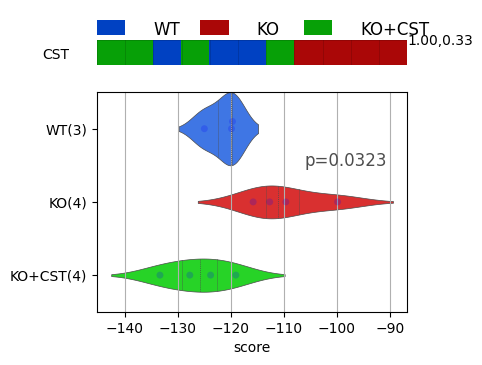

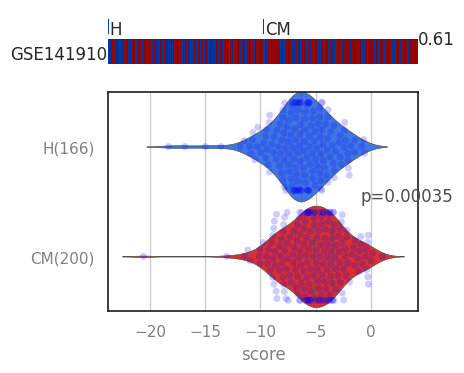

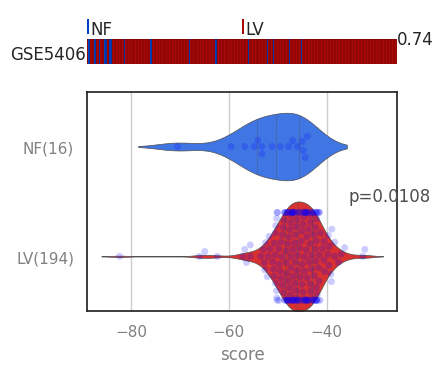

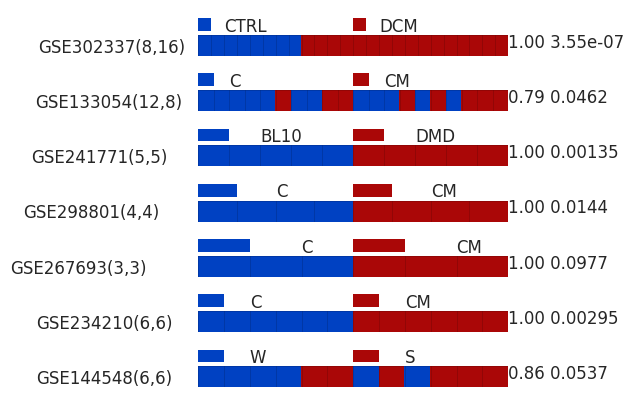

In [6]:
import bone
reload(bone)
import Datasets
reload(Datasets)
cfile = "data/sm-heart-w-ko-diff.txt"
df = mut.pd.read_csv(cfile, sep="\t", header=None)
df.columns=["ID", "Name", "T", "P", "Diff"]
df2 = df[(df['T'] < -1)]
cfile = "data/sm-heart-ko-cst-diff.txt"
df = mut.pd.read_csv(cfile, sep="\t", header=None)
df.columns=["ID", "Name", "T", "P", "Diff"]
df3 = df[(df['T'] > 1)]
cfile = "data/sm-heart-w-cst-diff.txt"
df = mut.pd.read_csv(cfile, sep="\t", header=None)
df.columns=["ID", "Name", "T", "P", "Diff"]
df4 = df[(abs(df['T']) < 2)]
deg1 = bone.getGroupsHs([list(df2['Name'].values)])[0]
deg2 = bone.getGroupsHs([list(df3['Name'].values)])[0]
deg3 = bone.getGroupsHs([list(df4['Name'].values)])[0]
deg = set(deg1).intersection(deg2).intersection(deg3)
ana = bone.IBDAnalysis()
ana.prepareData("GL1", cfile="data/explore.conf")
dcnlolo = hu.uniq([ana.h.getSimpleName(k) for k in dcres[2]])
dcnlolo = [i for i in dcnlolo if i != '---']
names = list(set(deg).intersection(dcnlolo))
print(len(names), ' '.join(names))
wt1, l1 = [1], [names]
mut.acolor = ['#0041C2', '#AA0707', '#07A007']
bone.acolor = ['#0041C2', '#AA0707', '#07A007']
ana = bone.IBDAnalysis()
ana.getSMheart()
ana.orderData(l1, wt1)
fig = mut.plotViolinBar(ana, 'CST')
ana.printAllPvals()

ana.getMorley2019(2)
ana.orderData(l1, wt1)
fig = mut.plotViolinBar(ana, ana.h.getSource())
ana.printAllPvals()

ana.getHannenhalli2006()
ana.orderData(l1, wt1)
fig = mut.plotViolinBar(ana, ana.h.getSource())
ana.printAllPvals()

def plotBar(ana, ax, l1, wt1):
    ana.orderData(l1, wt1)
    params = {'spaceAnn': len(ana.order)/len(ana.atypes),
              'tAnn': 1, 'widthAnn':1, 'acolor': bone.acolor,
              'w': 5, 'h': 0.8, 'atypes': ana.atypes ,'cval': ana.cval, 'ax': ax}
    ax = ana.printTitleBar(params)
    ax.text(-1, 2, ana.h.getSource() + f"({len(ana.state[0])},{len(ana.state[1])})",
            horizontalalignment='right', verticalalignment='center')
    actual = [1 if ana.aval[i] >= 1 else 0 for i in ana.i1]
    score = [ana.f_ranks[i - ana.start] for i in ana.i1]
    fpr, tpr, thrs = bone.roc_curve(actual, score, pos_label=1)
    v1 = [ana.f_ranks[i-2] for i in ana.state[0]]
    v2 = [ana.f_ranks[i-2] for i in ana.state[1]]
    m1 = bone.np.mean(v1)
    m2 = bone.np.mean(v2)
    sd = bone.np.std(v1 + v2)
    if sd == 0:
        sd = 1
    es = abs(m2 - m1)/sd
    t, p = bone.ttest_ind(v1,v2, equal_var=False)
    roc_auc = "%.2f %.3g" % (bone.auc(fpr, tpr), p)
    ax.text(len(ana.cval[0]), 2, roc_auc)
    return ax

fig,axes = bone.plt.subplots(ncols=1, nrows=7, figsize=(4,5), dpi=100)
ana = bone.IBDAnalysis()
ana.getKatoh2025Heart() # Works
ax = plotBar(ana, axes[0], l1, wt1)
ana.getRen2020Mm(2) #Works
ax = plotBar(ana, axes[1], l1, wt1)
ana.getDeMasi2024Mm(2) # Works
ax = plotBar(ana, axes[2], l1, wt1)
ana.getGrueter2025heartMm() # Works
ax = plotBar(ana, axes[3], l1, wt1)
ana.getPavelec2025heartMm(2) # Works
ax = plotBar(ana, axes[4], l1, wt1)
ana.getBakshi2025heartMm(2) # Works
ax = plotBar(ana, axes[5], l1, wt1)
ana.getPeng2020htnRt(2) #Works
ax = plotBar(ana, axes[6], l1, wt1)

## Figure 2

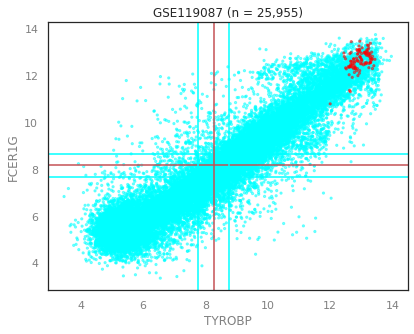

In [7]:
ana = bone.IBDAnalysis()
ana.prepareData("GL1", cfile="data/explore.conf")
w,h = (6.4, 4.8)
dpi = 100
fig = bone.plt.figure(figsize=(w,h))
ax = fig.add_axes([70.0/w/dpi, 54.0/h/dpi, 1-2*70.0/w/dpi, 1-2*54.0/h/dpi])
df = pd.DataFrame()
id1 = '204122_at'
id2 = '204232_at'
df['TYROBP'] = pd.to_numeric(ana.h.getExprData(id1)[2:])
df['FCER1G'] = pd.to_numeric(ana.h.getExprData(id2)[2:])
atype = ana.h.getSurvName('c Macrophage')
ahash = {'0':'cyan', '1':'red'}
df['color'] = [ahash[atype[i+2]] if atype[i+2] in ahash
               else None for i in df.index]

ax = df[df['color'] == 'cyan'].dropna().plot.scatter("TYROBP", "FCER1G", c="color", 
                                                     s=5, alpha=0.5,
                rasterized=True, title='GSE119087 (n = 25,955)', ax=ax)
ax = df[df['color'] == 'red'].dropna().plot.scatter("TYROBP", "FCER1G", c="color",
                                                    s=5, alpha=0.5,
                rasterized=True, title='GSE119087 (n = 25,955)', ax=ax)
thrx = ana.h.getThrData(id1)
thry = ana.h.getThrData(id2)
ax.axhline(y=float(thry[0]), color='r')
ax.axhline(y=float(thry[2]), color='cyan')
ax.axhline(y=float(thry[3]), color='cyan')
ax.axvline(x=float(thrx[0]), color='r')
ax.axvline(x=float(thrx[2]), color='cyan')
ax.axvline(x=float(thrx[3]), color='cyan')

34 IRAK3 RASGRP4 CCL18 FPR2 RDH16 SIGLEC10 FABP4 ADH1B FPR3 MPL IFNG CD8A HDC KLRB1 CSF2RA MS4A14 ACRBP MS4A3 CCL7 SRGN IL17RA OR2W3 CD300C MS4A4A CLEC4E STAB1 FES CCL8 CRP ADORA3 CAMP IL18RAP FGR CLEC12B
Suborno 2025 heart mm (n = 11)
GSE301063 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=SM1
11 [3, 4, 4] GSE301063 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=SM1 SM1
[30]
WT vs KO 5.56, 0.00292
WT vs KO+CST 0.809, 0.455
KO vs KO+CST -4.73, 0.00406
Morley 2019 heart (n = 366)
GSE141910 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV109
366 [166, 200] GSE141910 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV109 COV109
[28]


/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 18.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 30.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


H vs CM 5.55, 5.59e-08
Hannenhalli 2006 heart (n = 210)
GSE5406 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV113
210 [16, 194] GSE5406 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV113 COV113
[41]


/mnt/booleanfs2/sahoo/Data/BooleanLab/venv/lib/python3.6/site-packages/seaborn/categorical.py:1296: UserWarning: 21.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


NF vs LV 1.28, 0.216
Katoh 2025 heart scblk (n = 24)
GSE302337 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA48
20 [8, 12] GSE302337 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA48 CA48
[34]
De Masi 2024 dmd mm (n = 44)
GSE241771 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=MUSCLE24
10 [5, 5] GSE241771 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=MUSCLE24 MUSCLE24
[30]
Pavelec 2025 heart mm (n = 23)
GSE267693 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA51
6 [3, 3] GSE267693 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA51 CA51
[30]
Peng 2020 heart rat (n = 18)
GSE144548 http://hegemon.ucsd.edu/Tools/explore.php?key=heart&id=HRT6
12 [6, 6] GSE144548 http://hegemon.ucsd.edu/Tools/explore.php?key=heart&id=HRT6 HRT6
[27]
Khassafi 2023 heart rt (n = 67)
GSE240921 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA40.2
36 [18, 18] GSE240921 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA40.2 CA40.2
[25

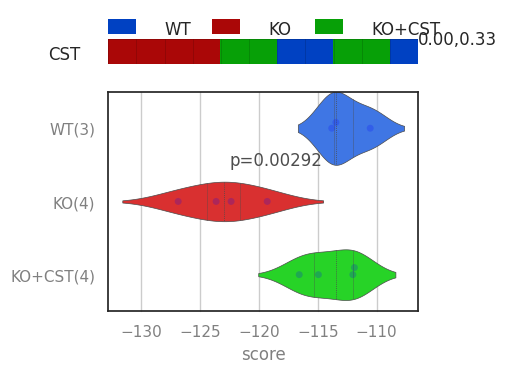

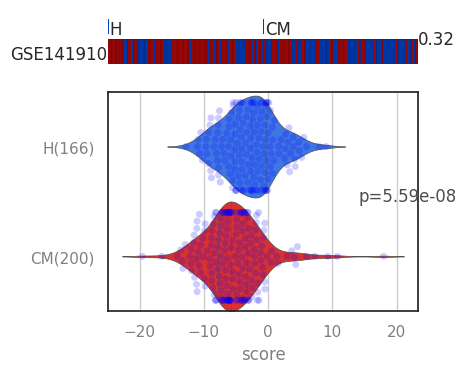

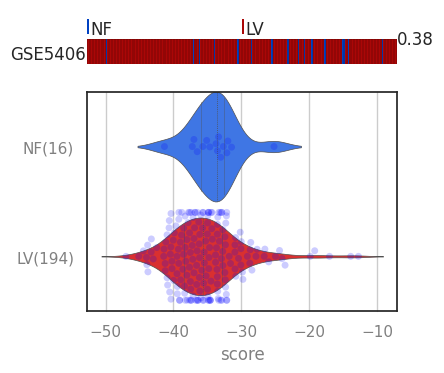

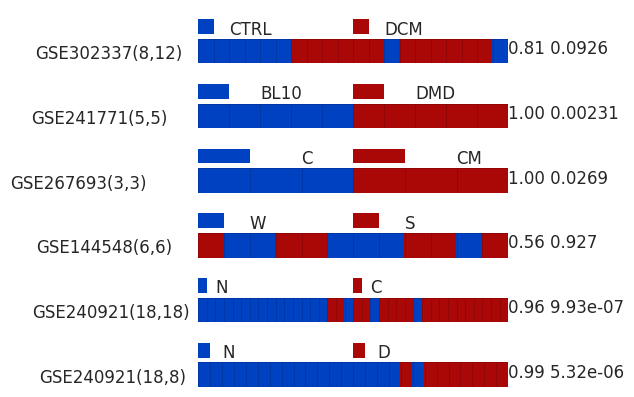

In [8]:
import bone
reload(bone)
import Datasets
reload(Datasets)
cfile = "data/sm-heart-w-ko-diff.txt"
df = mut.pd.read_csv(cfile, sep="\t", header=None)
df.columns=["ID", "Name", "T", "P", "Diff"]
df2 = df[(df['T'] > 1)]
cfile = "data/sm-heart-ko-cst-diff.txt"
df = mut.pd.read_csv(cfile, sep="\t", header=None)
df.columns=["ID", "Name", "T", "P", "Diff"]
df3 = df[(df['T'] < -1)]
cfile = "data/sm-heart-w-cst-diff.txt"
df = mut.pd.read_csv(cfile, sep="\t", header=None)
df.columns=["ID", "Name", "T", "P", "Diff"]
df4 = df[(abs(df['T']) < 2)]
deg1 = bone.getGroupsHs([list(df2['Name'].values)])[0]
deg2 = bone.getGroupsHs([list(df3['Name'].values)])[0]
deg3 = bone.getGroupsHs([list(df4['Name'].values)])[0]
deg = set(deg1).intersection(deg2).intersection(deg3)
ana = bone.IBDAnalysis()
ana.prepareData("GL1", cfile="data/explore.conf")
tylolo = hu.uniq([ana.h.getSimpleName(k) for k in tyres[2]])
tylolo = [i for i in tylolo if i != '---']
names = list(set(deg).intersection(tylolo))
print(len(names), ' '.join(names))
wt1, l1 = [1], [names]
mut.acolor = ['#0041C2', '#AA0707', '#07A007']
ana = bone.IBDAnalysis()
ana.getSMheart()
ana.orderData(l1, wt1)
fig = mut.plotViolinBar(ana, 'CST')
ana.printAllPvals()

ana.getMorley2019(2)
ana.orderData(l1, wt1)
fig = mut.plotViolinBar(ana, ana.h.getSource())
ana.printAllPvals()

ana.getHannenhalli2006()
ana.orderData(l1, wt1)
fig = mut.plotViolinBar(ana, ana.h.getSource())
ana.printAllPvals()

bone.acolor = ['#0041C2', '#AA0707', '#07A007']
fig,axes = bone.plt.subplots(ncols=1, nrows=6, figsize=(4,5), dpi=100)
ana = bone.IBDAnalysis()
ana.getKatoh2025Heart(2) # Works
ax = plotBar(ana, axes[0], l1, wt1)
ana.getDeMasi2024Mm(2) # Works
ax = plotBar(ana, axes[1], l1, wt1)
ana.getPavelec2025heartMm(2) # Works
ax = plotBar(ana, axes[2], l1, wt1)
ana.getPeng2020htnRt(2) #Works
ax = plotBar(ana, axes[3], l1, wt1)
ana.getKhassafi2023htnRt(3) # Works
ax = plotBar(ana, axes[4], l1, wt1)
ana.getKhassafi2023htnRt(4) # Works
ax = plotBar(ana, axes[5], l1, wt1)


26 CD209 VSIG4 LILRA6 ITGAM LILRB4 LILRA1 PLA2G2D AOAH LILRB1 TLR8 PHOSPHO1 CD300LF SLC46A2 LILRB5 LILRB2 LILRA5 LILRB3 IL6R CSF1R LILRA2 SIGLEC1 SLC24A4 SIRPB1 TIMD4 C1orf162 SIRPG
Suborno 2025 heart mm (n = 11)
GSE301063 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=SM1
11 [3, 4, 4] GSE301063 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=SM1 SM1
[14]
WT vs KO -2.81, 0.0403
WT vs KO+CST 0.64, 0.551
KO vs KO+CST 2.96, 0.0291
Li 2020 heart (n = 15)
GSE107480 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV107
15 [6, 9] GSE107480 http://hegemon.ucsd.edu/Tools/explore.php?key=covid&id=COV107 COV107
[26]
LV vs ARV -2.51, 0.0263
Katoh 2025 heart scblk (n = 24)
GSE302337 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA48
20 [8, 12] GSE302337 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=CA48 CA48
[26]
De Masi 2024 dmd mm (n = 44)
GSE241771 http://hegemon.ucsd.edu/Tools/explore.php?key=polyps&id=MUSCLE24
10 [5, 5] GSE241771 http://hegemon.ucsd

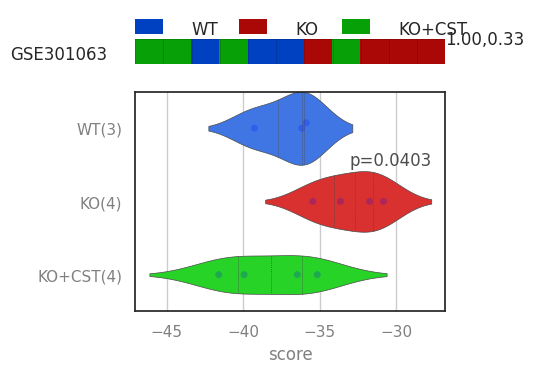

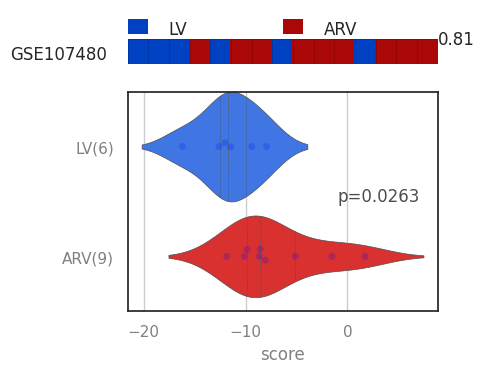

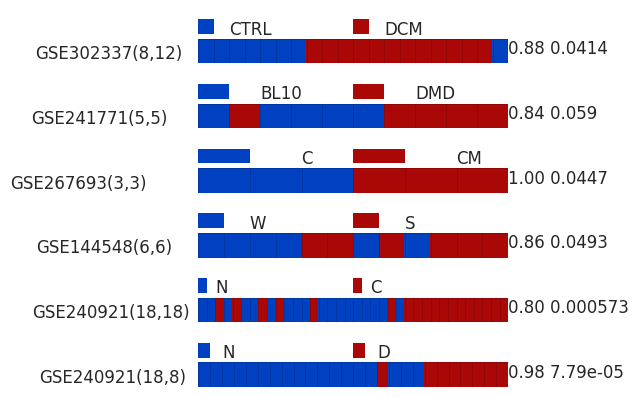

In [9]:
cfile = "data/sm-heart-w-ko-diff.txt"
df = mut.pd.read_csv(cfile, sep="\t", header=None)
df.columns=["ID", "Name", "T", "P", "Diff"]
df2 = df[(df['T'] < -1.5)]
cfile = "data/sm-heart-ko-cst-diff.txt"
df = mut.pd.read_csv(cfile, sep="\t", header=None)
df.columns=["ID", "Name", "T", "P", "Diff"]
df3 = df[(df['T'] > 1.5)]
cfile = "data/sm-heart-w-cst-diff.txt"
df = mut.pd.read_csv(cfile, sep="\t", header=None)
df.columns=["ID", "Name", "T", "P", "Diff"]
df4 = df[(abs(df['T']) < 2)]
deg1 = bone.getGroupsHs([list(df2['Name'].values)])[0]
deg2 = bone.getGroupsHs([list(df3['Name'].values)])[0]
deg3 = bone.getGroupsHs([list(df4['Name'].values)])[0]
deg = set(deg1).intersection(deg2).intersection(deg3)
ana = bone.IBDAnalysis()
ana.prepareData("GL1", cfile="data/explore.conf")
tylolo = hu.uniq([ana.h.getSimpleName(k) for k in tyres[2]])
tylolo = [i for i in tylolo if i != '---']
names = list(set(deg).intersection(tylolo))
print(len(names), ' '.join(names))
wt1, l1 = [1], [names]
mut.acolor = ['#0041C2', '#AA0707', '#07A007']
bone.acolor = ['#0041C2', '#AA0707', '#07A007']
ana = bone.IBDAnalysis()
ana.getSMheart()
ana.orderData(l1, wt1)
fig = mut.plotViolinBar(ana, ana.h.getSource())
ana.printAllPvals()

ana.getLi2020() #I Up
ana.orderData(l1, wt1)
fig = mut.plotViolinBar(ana, ana.h.getSource())
ana.printAllPvals()

bone.acolor = ['#0041C2', '#AA0707', '#07A007']
fig,axes = bone.plt.subplots(ncols=1, nrows=6, figsize=(4,5), dpi=100)
ana = bone.IBDAnalysis()
ana.getKatoh2025Heart(2) # Works
ax = plotBar(ana, axes[0], l1, wt1)
ana.getDeMasi2024Mm(2) # Works
ax = plotBar(ana, axes[1], l1, wt1)
ana.getPavelec2025heartMm(2) # Works
ax = plotBar(ana, axes[2], l1, wt1)
ana.getPeng2020htnRt(2) #Works
ax = plotBar(ana, axes[3], l1, wt1)
ana.getKhassafi2023htnRt(3) # Works
ax = plotBar(ana, axes[4], l1, wt1)
ana.getKhassafi2023htnRt(4) # Works
ax = plotBar(ana, axes[5], l1, wt1)